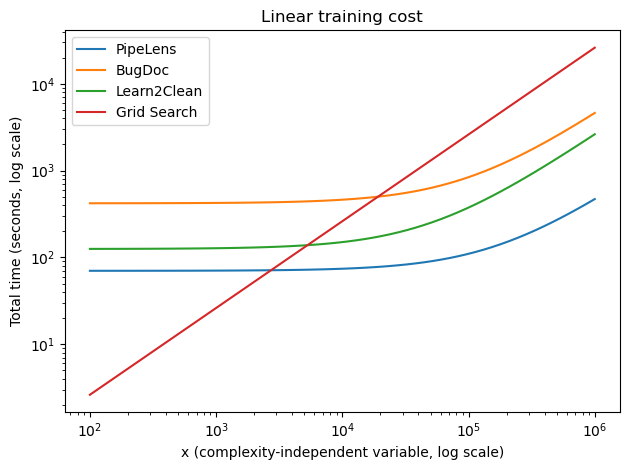

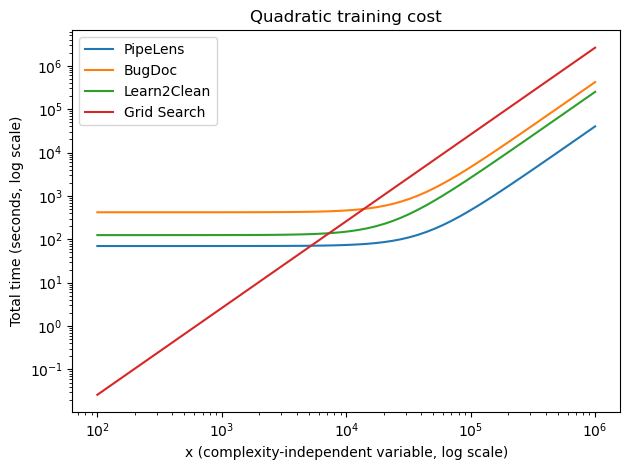

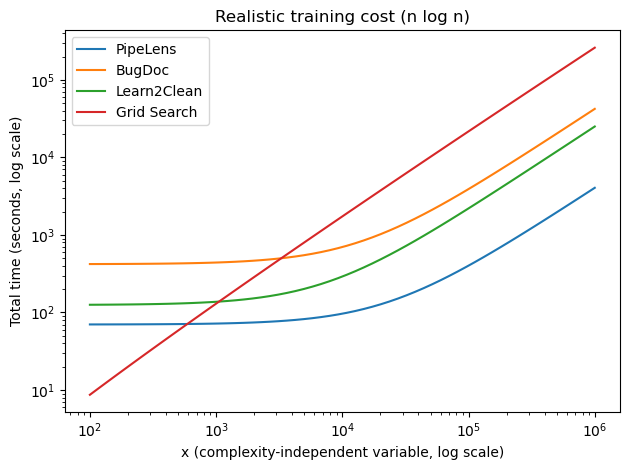

In [1]:
import numpy as np
import matplotlib.pyplot as plt


a = 1e-4        
b = 1e-8         
c = 5e-5  

N_PIPELENS = 4
N_BUGDOC   = 42
N_L2C      = 25
N_GRID     = 261

FIX_PIPELENS_ONCE = 70.0 
FIX_BUGDOC_PER    = 10.0
FIX_L2C_PER       = 5
FiX_GRID_PER      = 1


x = np.geomspace(100, 1e6, 60)

def train_time_linear(x):
    return a * x

def train_time_quadratic(x):
    return b * x**2

def train_time_realistic(x):
    return c * x * np.log2(x + 1.0)

def total_time(framework_name, train_time):
    """Return total runtime arrays for a given per-model train_time(x)."""
    t_train = train_time(x)
    if framework_name == "PipeLens":
        return FIX_PIPELENS_ONCE + (N_PIPELENS * t_train)
    if framework_name == "BugDoc":
        return N_BUGDOC * (t_train + FIX_BUGDOC_PER)
    if framework_name == "Learn2Clean":
        return N_L2C * (t_train + FIX_L2C_PER)
    if framework_name == "Grid Search":
        return N_GRID * t_train
    raise ValueError("Unknown framework")

frameworks = ["PipeLens", "BugDoc", "Learn2Clean", "Grid Search"]
complexities = [
    ("Linear training cost", train_time_linear),
    ("Quadratic training cost", train_time_quadratic),
    ("Realistic training cost (n log n)", train_time_realistic),
]

# ------------------------- Plotting -------------------------
for title, tt in complexities:
    plt.figure()
    for fw in frameworks:
        y = total_time(fw, tt)
        plt.plot(x, y, label=fw)  # single plot, no seaborn, no explicit colors
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x (complexity-independent variable, log scale)")
    plt.ylabel("Total time (seconds, log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

plt.show()


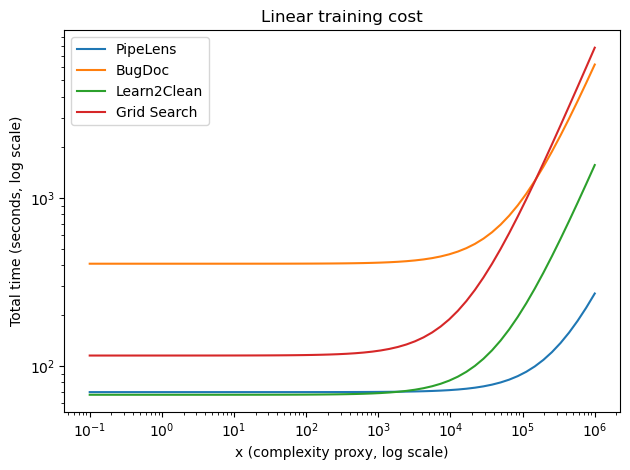

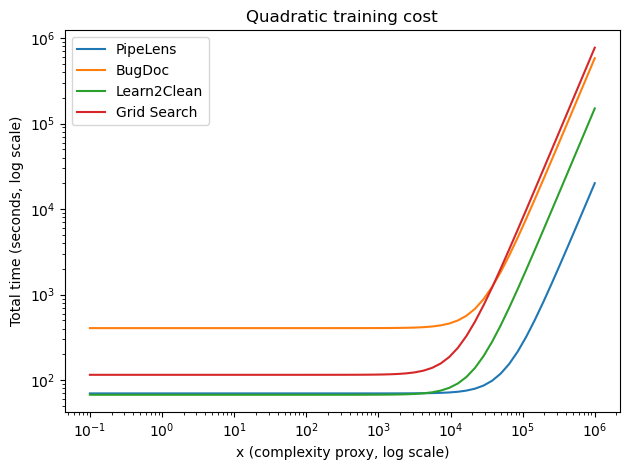

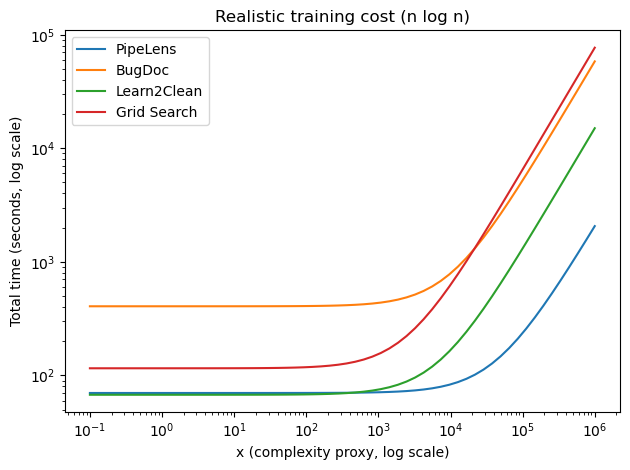

In [97]:


import numpy as np
import matplotlib.pyplot as plt



a = 1e-4
b = 1e-8
c = 5e-5


K_PIPELENS = 2
N_BUGDOC   = 58
N_L2C      = 15
N_GRID     = 77

FIX_PIPELENS_ONCE = 70.0
FIX_BUGDOC_PER    = 7.0
FIX_L2C_PER       = 4.5
FiX_GRID_PER      = 1.5

x = np.geomspace(.1, 1e6, 60)

def train_time_linear(x):
    return a * x

def train_time_quadratic(x):
    return b * x**2

def train_time_realistic(x):
    return c * x * np.log2(x + 1.0)



def total_time_pipelens(t_train):
    return FIX_PIPELENS_ONCE + K_PIPELENS  * t_train(x)

def total_time_bugdoc(t_train):
    fixed = N_BUGDOC * FIX_BUGDOC_PER
    return fixed + N_BUGDOC * t_train(x)

def total_time_l2c(t_train):
    fixed = N_L2C * FIX_L2C_PER

    return fixed + N_L2C * t_train(x)

def total_time_grid(t_train):
    fixed= N_GRID*FiX_GRID_PER
    return fixed+(N_GRID * t_train(x))

frameworks = [
    ("PipeLens", total_time_pipelens),
    ("BugDoc", total_time_bugdoc),
    ("Learn2Clean", total_time_l2c),
    ("Grid Search", total_time_grid),
]

complexities = [
    ("Linear training cost", train_time_linear),
    ("Quadratic training cost", train_time_quadratic),
    ("Realistic training cost (n log n)", train_time_realistic),
]


paths = []
for title, tfunc in complexities:
    plt.figure()
    for name, tfw in frameworks:
        y = tfw(tfunc)
        plt.plot(x, y, label=name)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("x (complexity proxy, log scale)")
    plt.ylabel("Total time (seconds, log scale)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



Saved plot to: /Users/hasan89/Documents/PipeLens_Plot/complexity_simulation.pdf


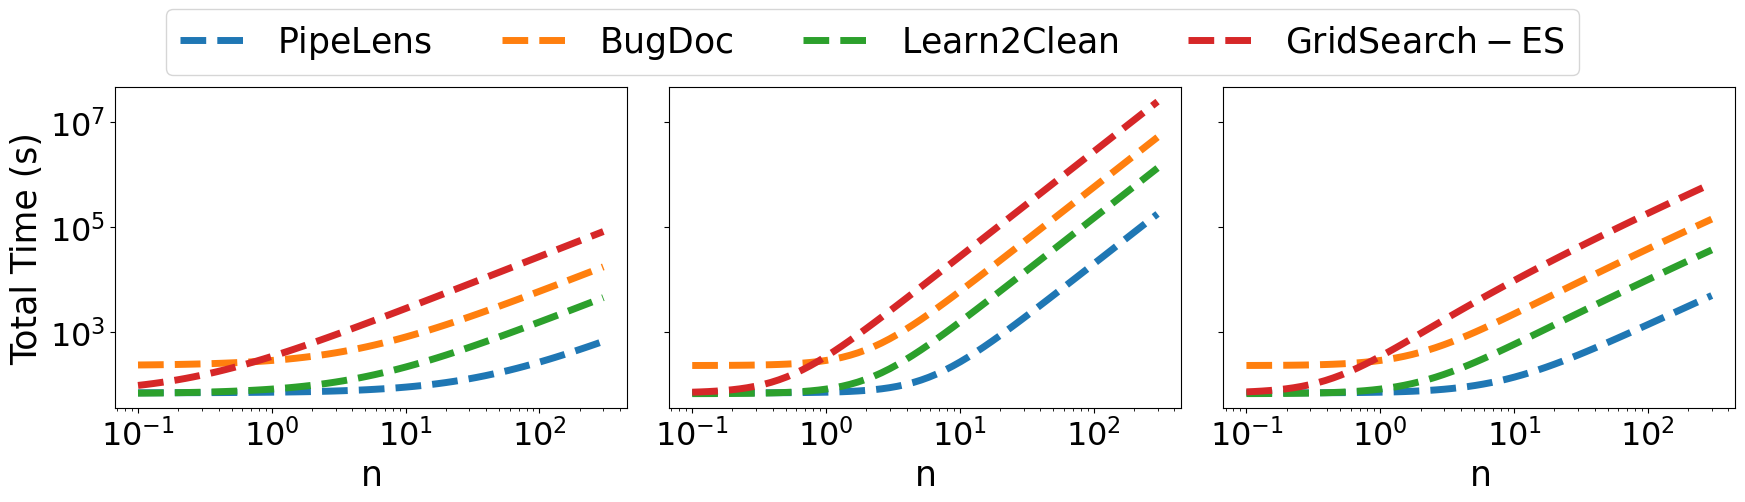

In [34]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl

# -------- Do NOT use LaTeX; keep mathtext --------
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'
mpl.rcParams['font.family'] = 'sans-serif'

# ================= Font & saving config =================
fsize = 25
params = {'legend.fontsize': fsize, 'legend.handlelength': 2}
matplotlib.rcParams.update(params)

matplotlib.rc('font', family='sans-serif', size=fsize)
matplotlib.rcParams.update({
    'axes.titlesize': fsize,
    'axes.labelsize': fsize,
    'xtick.labelsize': fsize-2,
    'ytick.labelsize': fsize-2,
})

# ================= Save path setup =================
task = globals().get('task', 'Runtime')
case = globals().get('case', 'AllMethods')

folder_path = '/Users/hasan89/Documents/PipeLens_Plot'
file_name = f"complexity_simulation.pdf"
os.makedirs(folder_path, exist_ok=True)
file_path = os.path.join(folder_path, file_name)

# ================= Scenario constants =================
a = 1e-4
b = 1e-8
c = 5e-5

K_PIPELENS = 2
N_BUGDOC   = 58
N_L2C      = 15
N_GRID     = 277

FIX_PIPELENS_ONCE = 70.0
FIX_BUGDOC_PER    = 4.0
FIX_L2C_PER       = 4.5
FiX_GRID_PER      = .25

x = np.geomspace(1e-1, 3*1e2, 60)

# --- training cost functions ---
def train_time_linear(x):     return x
def train_time_quadratic(x):  return x**2
def train_time_realistic(x):  return x * np.log2(x + 1.0)

# --- framework cost ---
def total_time_pipelens(t_train): return FIX_PIPELENS_ONCE + K_PIPELENS * t_train(x)
def total_time_bugdoc(t_train):   return N_BUGDOC * FIX_BUGDOC_PER + N_BUGDOC * t_train(x)
def total_time_l2c(t_train):      return N_L2C * FIX_L2C_PER + N_L2C * t_train(x)
def total_time_grid(t_train):     return N_GRID * FiX_GRID_PER + N_GRID * t_train(x)

frameworks = [
    (r"$\mathrm{PipeLens}$",      total_time_pipelens),
    (r"$\mathrm{BugDoc}$",        total_time_bugdoc),
    (r"$\mathrm{Learn2Clean}$",   total_time_l2c),
    (r"$\mathrm{GridSearch-ES}$", total_time_grid),
]

complexities = [
    (r"$ \mathcal{O}(n)$",        train_time_linear),
    (r"$ \mathcal{O}(n^{2})$",    train_time_quadratic),
    (r"$ \mathcal{O}(n\log n)$",  train_time_realistic),
]

# ================= Plot =================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)

for ax, (title, tfunc) in zip(axes, complexities):
    for name, tfw in frameworks:
        y = tfw(tfunc)
        ax.plot(
            x, y,
            label=name,
            linestyle='--',   # dashed line
            linewidth=5.0     # thicker lines
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    #ax.set_title(title)
    ax.set_xlabel(r"$n$")

axes[0].set_ylabel(r"Total Time (s)")

# --- shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=len(frameworks), bbox_to_anchor=(0.5, 1.12))

plt.tight_layout()
plt.savefig(file_path, format='pdf', bbox_inches='tight')
print(f"Saved plot to: {file_path}")

plt.show()


Saved single-plot (O(n)) to: /Users/hasan89/Documents/PipeLens_Plot/complexity_simulation_linear_only.pdf


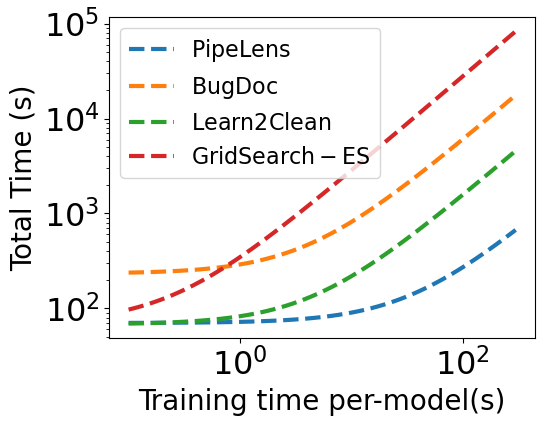

In [45]:
# ===== Single-plot figure: only the first complexity (O(n)) =====
single_title, single_tfunc = complexities[0]  # first = O(n)

file_name_first = "complexity_simulation_linear_only.pdf"
file_path_first = os.path.join(folder_path, file_name_first)

fig1, ax1 = plt.subplots(figsize=(6, 4.8))
for name, tfw in frameworks:
    y = tfw(single_tfunc)
    ax1.plot(
        x, y,
        label=name,
        linestyle='--',   # dashed lines (as you requested)
        linewidth=3.0
    )

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel('Training time per-model(s)', fontsize=20)
ax1.set_ylabel('Total Time (s)', fontsize=20)
ax1.legend(loc="best", ncol=1, fontsize=16)

plt.tight_layout()
plt.savefig(file_path_first, format='pdf', bbox_inches='tight')
print(f"Saved single-plot (O(n)) to: {file_path_first}")
plt.show()


In [ ]:
# Running your plotting code but saving to the sandbox so you can download it here.
# On your machine, keep your original `folder_path`.

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ================= Font & saving config =================
fsize = 20
params = {'legend.fontsize': fsize, 'legend.handlelength': 2}
matplotlib.rcParams.update(params)

# use sans-serif + global sizes
matplotlib.rc('font', family='sans-serif', size=fsize)
matplotlib.rcParams.update({
    'axes.titlesize': fsize,
    'axes.labelsize': fsize,
    'xtick.labelsize': fsize-2,
    'ytick.labelsize': fsize-2,
})

# set these before saving
task = 'Runtime'
case = 'AllMethods'

folder_path = '/mnt/data'  # sandbox path for download
file_name = f"{task}_{case}.pdf"

os.makedirs(folder_path, exist_ok=True)
file_path = os.path.join(folder_path, file_name)

# ================= Scenario constants =================
a = 1e-4
b = 1e-8
c = 5e-5

K_PIPELENS = 2
N_BUGDOC   = 58
N_L2C      = 15
N_GRID     = 77

FIX_PIPELENS_ONCE = 70.0
FIX_BUGDOC_PER    = 7.0
FIX_L2C_PER       = 4.5
FiX_GRID_PER      = 1.5  # (kept as-is)

x = np.geomspace(1e-1, 1e6, 60)  # >0 for log scale

# ================= Per-model training times =================
def train_time_linear(x):     return a * x
def train_time_quadratic(x):  return b * x**2
def train_time_realistic(x):  return c * x * np.log2(x + 1.0)

# ================= Total time per framework =================
def total_time_pipelens(t_train):
    return FIX_PIPELENS_ONCE + K_PIPELENS * t_train(x)

def total_time_bugdoc(t_train):
    fixed = N_BUGDOC * FIX_BUGDOC_PER
    return fixed + N_BUGDOC * t_train(x)

def total_time_l2c(t_train):
    fixed = N_L2C * FIX_L2C_PER
    return fixed + N_L2C * t_train(x)

def total_time_grid(t_train):
    fixed = N_GRID * FiX_GRID_PER
    return fixed + N_GRID * t_train(x)

frameworks = [
    ("PipeLens", total_time_pipelens),
    ("BugDoc", total_time_bugdoc),
    ("Learn2Clean", total_time_l2c),
    ("Grid Search", total_time_grid),
]

# --- Use math notation for titles ---
complexities = [
    (r"$O(n)$",            train_time_linear),
    (r"$O(n^2)$",          train_time_quadratic),
    (r"$O(n\log n)$",      train_time_realistic),
]

# ================= Plot: 1×3 subplots =================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex


RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x12f2dee80> (for post_execute):


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1800x480 with 3 Axes>